# Automated Computation of Distal Femoral Osteotomy Correction Angles

This project aims to automate the detection of key anatomical landmarks (such as the hip center, distal femur, and ankle center) in long-leg radiographs (X-rays). By accurately locating these components using a YOLO architecture, we can automatically calculate the mechanical axis and the necessary surgical correction angles for a Distal Femoral Osteotomy (DFO).

## Imports

Import standard data handling, computer vision, and deep learning libraries essential for PyTorch and YOLO operations.

In [1]:
import os
import json
import random
import torch
import yaml
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

## GPU Availability Check

Validating hardware acceleration ensures efficiently trained computer vision models. Here we check the PyTorch version and query the presence and name of any available GPUs.

In [2]:
print(f"PyTorch version: {torch.__version__}")
gpu_available = torch.cuda.is_available()
print(f"GPU available: {gpu_available}")

if gpu_available:
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu130
GPU available: True
GPU Device Name: NVIDIA GeForce RTX 4070 Laptop GPU


## Data Preparation & Exploratory Data Analysis

Before training our YOLO model, we parse the MS COCO JSON ground truth file to structure the X-ray image data and its YOLO-format label files. We dynamically locate these files, shuffle them to prevent any ordering bias, split them into training, validation, and testing sets, and build the configuration YAML.

### Configuration

Here we define the core paths, target anatomical landmark classes, the desired split ratios across train/val/test, and other global training hyperparameters.

In [3]:
# Configuration Paths & Hyperparameters
DATA_DIR = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "_annotations_keypoints.coco.json")
CLASSES = ["hip", "distal_femur", "ankle"]
SPLIT_RATIOS = (0.8, 0.1, 0.1)  # 80% Train, 10% Validation, 10% Test

# Model Hyperparameters
EPOCHS = 100
IMGSZ = 640
BATCH_SIZE = 16

### Dynamic Dataset Splitting & COCO to YOLO Conversion

We load the MS COCO JSON file containing object annotations (bounding boxes), normalize the coordinates into YOLO format (`x_center, y_center, width, height`), perform a randomized shuffle, and generate the required train/val/test text files which are then indexed in the `data.yaml`.

In [4]:
def prepare_dataset(data_dir, coco_json_path, output_dir="yolo_data"):
    """Converts MS COCO JSON annotations to YOLO format, shuffles images, and creates train/val/test splits."""
    os.makedirs(output_dir, exist_ok=True)
    
    if not os.path.exists(coco_json_path) or not os.path.exists(data_dir):
        print("Warning: Data directory or COCO JSON does not exist. Generating dummy data for dry run...")
        # Create a dummy COCO JSON structure in memory
        dummy_coco = {
            "images": [{"id": i, "file_name": f"sample_{i}.jpg", "width": 1000, "height": 1000} for i in range(100)],
            "annotations": [{"image_id": i, "category_id": random.randint(1, 3), "bbox": [200, 300, 100, 150], "id": i} for i in range(100)],
            "categories": [{"id": 1, "name": "hip"}, {"id": 2, "name": "distal_femur"}, {"id": 3, "name": "ankle"}]
        }
        coco_data = dummy_coco
    else:
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
            
    # Create category mapping
    cat_id_to_name = {cat["id"]: cat["name"] for cat in coco_data.get("categories", [])}
    name_to_yolo_id = {name: idx for idx, name in enumerate(CLASSES)}
    
    # Map image IDs to their info and annotations
    images_info = {img["id"]: img for img in coco_data.get("images", [])}
    annotations_by_img = {img_id: [] for img_id in images_info}
    
    for ann in coco_data.get("annotations", []):
        img_id = ann.get("image_id")
        if img_id in annotations_by_img:
            annotations_by_img[img_id].append(ann)
            
    valid_images = list(images_info.keys())
    if not valid_images:
        raise ValueError("No images found in the COCO JSON file.")
        
    # Randomly shuffle images
    random.shuffle(valid_images)
    
    # Calculate split boundaries
    num_imgs = len(valid_images)
    train_end = int(num_imgs * SPLIT_RATIOS[0])
    val_end = train_end + int(num_imgs * SPLIT_RATIOS[1])
    
    splits = {
        "train": valid_images[:train_end],
        "val": valid_images[train_end:val_end],
        "test": valid_images[val_end:]
    }
    
    split_files = {}
    for split_name, img_ids in splits.items():
        images_split_dir = os.path.join(output_dir, "images", split_name)
        labels_split_dir = os.path.join(output_dir, "labels", split_name)
        os.makedirs(images_split_dir, exist_ok=True)
        os.makedirs(labels_split_dir, exist_ok=True)
        
        split_img_paths = []
        for img_id in img_ids:
            img_info = images_info[img_id]
            img_filename = img_info["file_name"]
            src_path = os.path.join(data_dir, img_filename)
            dst_img_path = os.path.join(images_split_dir, os.path.basename(img_filename))
            
            # Either symlink/copy the image or create a dummy file if dry run
            if os.path.exists(src_path):
                if not os.path.exists(dst_img_path):
                    os.symlink(src_path, dst_img_path)
            else:
                # Create dummy file for dry run
                open(dst_img_path, "w").close()
                
            # Convert annotations and write YOLO txt file
            # COCO bbox: [x_min, y_min, width, height]
            txt_filename = os.path.splitext(os.path.basename(img_filename))[0] + ".txt"
            txt_path = os.path.join(labels_split_dir, txt_filename)
            
            with open(txt_path, "w") as f:
                img_w = img_info.get("width", 1000)
                img_h = img_info.get("height", 1000)
                for ann in annotations_by_img[img_id]:
                    bbox = ann.get("bbox", [0, 0, 0, 0])
                    cat_id = ann.get("category_id")
                    cat_name = cat_id_to_name.get(cat_id)
                    if cat_name in name_to_yolo_id:
                        yolo_idx = name_to_yolo_id[cat_name]
                        # Convert to normalized center format
                        x_center = (bbox[0] + bbox[2] / 2.0) / img_w
                        y_center = (bbox[1] + bbox[3] / 2.0) / img_h
                        width = bbox[2] / img_w
                        height = bbox[3] / img_h
                        f.write(f"{yolo_idx} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
            
            split_img_paths.append(os.path.abspath(dst_img_path))
            
        file_path = os.path.abspath(os.path.join(output_dir, f"{split_name}.txt"))
        with open(file_path, "w") as f:
            f.write("\n".join(split_img_paths))
        split_files[split_name] = file_path
        
    # Write the data.yaml for YOLO use
    yaml_data = {
        "train": split_files["train"],
        "val": split_files["val"],
        "test": split_files["test"],
        "nc": len(CLASSES),
        "names": CLASSES
    }
    
    yaml_path = os.path.abspath(os.path.join(output_dir, "data.yaml"))
    with open(yaml_path, "w") as f:
        yaml.dump(yaml_data, f, default_flow_style=False)
        
    return yaml_path

data_yaml_path = prepare_dataset(DATA_DIR, COCO_JSON_PATH)
print(f"Dataset configuration written to: {data_yaml_path}")

Dataset configuration written to: /tf/notebooks/yolo_data/data.yaml


### Sanity Check Visualization

Before running our expensive training process, we load and visualize 3-5 randomly chosen images and overlay their associated bounding boxes and labels. This confirms the spatial alignment of annotations.

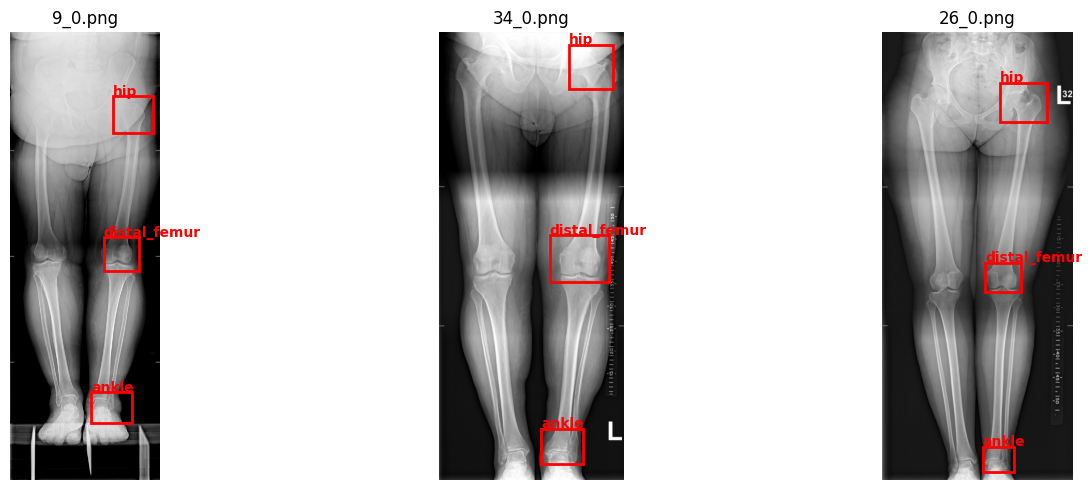

In [5]:
def show_random_samples(data_yaml, num_samples=3):
    with open(data_yaml, "r") as f:
        config = yaml.safe_load(f)
    
    with open(config["train"], "r") as f:
        images = f.read().splitlines()
        
    if not images:
        print("No images found to visualize.")
        return
        
    selected = random.sample(images, min(num_samples, len(images)))
    
    fig, axes = plt.subplots(1, len(selected), figsize=(15, 5))
    if len(selected) == 1:
        axes = [axes]
        
    for idx, img_path in enumerate(selected):
        ax = axes[idx]
        try:
            img = Image.open(img_path)
            ax.imshow(img, cmap='gray')
            w, h = img.size
            
            # Look for matching label file
            label_file = img_path.replace(os.path.join("images", ""), os.path.join("labels", "")).rsplit(".", 1)[0] + ".txt"
            if os.path.exists(label_file):
                with open(label_file, "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            cls_id = int(parts[0])
                            x_center, y_center, box_w, box_h = map(float, parts[1:5])
                            xmin = (x_center - box_w / 2) * w
                            ymin = (y_center - box_h / 2) * h
                            rect_w = box_w * w
                            rect_h = box_h * h
                            
                            rect = patches.Rectangle((xmin, ymin), rect_w, rect_h, 
                                                     linewidth=2, edgecolor='red', facecolor='none')
                            ax.add_patch(rect)
                            label = config["names"][cls_id] if cls_id < len(config["names"]) else str(cls_id)
                            ax.text(xmin, ymin - 5, label, color='red', weight='bold')
        except Exception as e:
            ax.set_title(f"Error loading {os.path.basename(img_path)}")
            continue
            
        ax.axis("off")
        ax.set_title(os.path.basename(img_path))
        
    plt.tight_layout()
    plt.show()

# Display the sanity check
if os.path.exists(DATA_DIR):
    show_random_samples(data_yaml_path, num_samples=3)
else:
    print("Data directory not found; skipping sanity check visualization in dry run.")

## Part 1: Regions of Interests Detection

### Model Initialization & Training

We instantiate the YOLO architecture and conduct the optimization process over our processed anatomical dataset.

#### Load Model

We load the lightweight pretrained YOLO26 architecture to warm-start our feature extractors.

In [6]:
print("Loading YOLO26 pretrained weights...")
model = YOLO("yolo26n.pt")

Loading YOLO26 pretrained weights...


#### Training Loop

Execute the primary training routine using our configuration YAML and predefined hyperparameters. YOLO handles optimization, checkpointing, and metric validation internally.

In [7]:
print("Starting YOLO training loop...")
results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    device=0,
    
    # Customizing augmentations for Medical Radiographs
    fliplr=0.5,    # Allow horizontal flips (left/right leg symmetry)
    flipud=0.0,    # Prevent upside-down hips/ankles
    degrees=5.0,   # Limit rotation to gentle patient tilts
    scale=0.1,     # Minor zoom-in/out scaling
    mosaic=1.0     # Keep mosaic active for small features
)
print("Training complete!")

Starting YOLO training loop...
Ultralytics 8.4.41 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tf/notebooks/yolo_data/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, opti

#### Training Progress

Visualize the resulting optimization progression by plotting both training and validation loss alongside the mean Average Precision (mAP) scores over time.

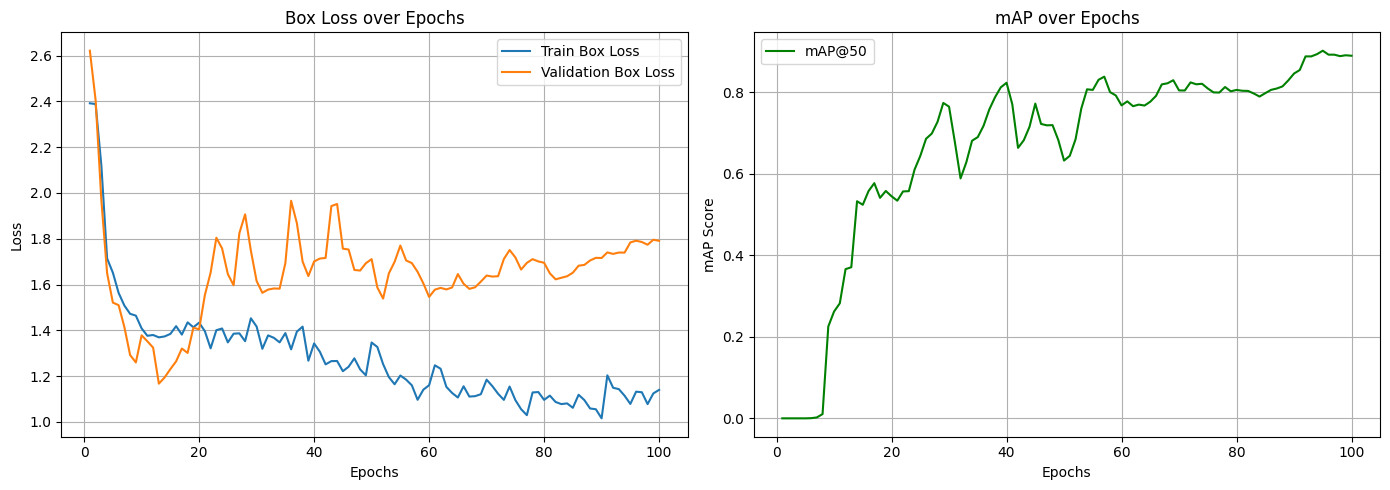

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Ultralytics typically outputs runs/detect/train/results.csv
results_path = os.path.join("runs", "detect", "train", "results.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Training and Validation Loss
    if "train/box_loss" in df.columns and "val/box_loss" in df.columns:
        ax1.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        ax1.plot(df["epoch"], df["val/box_loss"], label="Validation Box Loss")
        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Loss")
        ax1.set_title("Box Loss over Epochs")
        ax1.legend()
        ax1.grid(True)
        
    # Plot mAP over time
    map_col = [col for col in df.columns if "mAP50" in col]
    if map_col:
        ax2.plot(df["epoch"], df[map_col[0]], label="mAP@50", color="green")
        ax2.set_xlabel("Epochs")
        ax2.set_ylabel("mAP Score")
        ax2.set_title("mAP over Epochs")
        ax2.legend()
        ax2.grid(True)
        
    plt.tight_layout()
    plt.show()
else:
    print("Results CSV not found; check YOLO output run path. (Expected during dry runs or before training completes)")

### Evaluation & Inference

After training concludes, it is critical to evaluate our model's boundary box positioning and anatomical landmark identification on previously unseen test data.

#### Test Set Inference

Run validation metrics strictly over the held-out test split to ensure the model generalizes cleanly to new patient X-rays.

In [9]:
print("Running model validation on the test split...")
test_metrics = model.val(data=data_yaml_path, split="test")
print(f"Test Set mAP50: {test_metrics.box.map50:.4f}")
print(f"Test Set mAP50-95: {test_metrics.box.map:.4f}")

Running model validation on the test split...
Ultralytics 8.4.41 🚀 Python-3.11.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 3.5±0.4 ms, read: 181.0±4.2 MB/s, size: 7847.3 KB)
val: Scanning /tf/notebooks/yolo_data/labels/test... 7 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7/7 40.3it/s 0.2s.3s
val: New cache created: /tf/notebooks/yolo_data/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.7s/it 2.7s
                   all          7         21      0.663      0.748      0.786       0.42
                   hip          7          7      0.575      0.571      0.691      0.372
          distal_femur          7          7      0.565      0.857      0.823      0.477
                 ankle          7          7       0.85      0.814      0.844      0.412
Speed

#### Testing Metrics

Display standard PR curves, F1-score curves, and confusion matrix heatmaps generated during the testing stage.

F1_curve.png not found in runs/detect/val (Available after evaluation)
PR_curve.png not found in runs/detect/val (Available after evaluation)


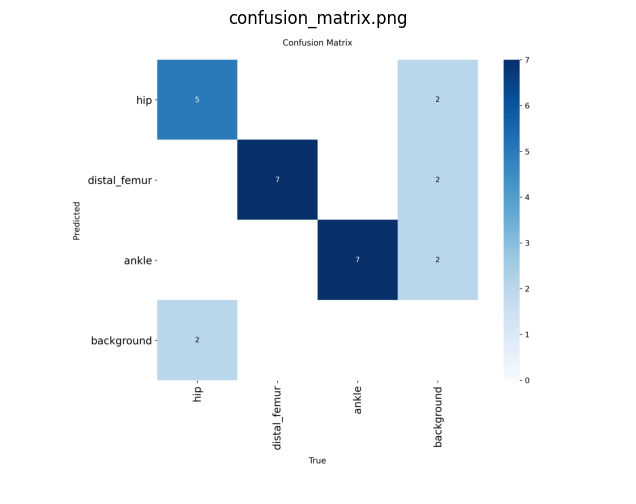

In [10]:
val_dir = os.path.join("runs", "detect", "val")
metric_plots = ["F1_curve.png", "PR_curve.png", "confusion_matrix.png"]

for plot_name in metric_plots:
    plot_path = os.path.join(val_dir, plot_name)
    if os.path.exists(plot_path):
        plt.figure(figsize=(10, 6))
        img = Image.open(plot_path)
        plt.imshow(img)
        plt.axis("off")
        plt.title(plot_name)
        plt.show()
    else:
        print(f"{plot_name} not found in {val_dir} (Available after evaluation)")

#### Result Inspection

Load and visualize raw prediction overlays alongside ground truth boxes on the test dataset so clinicians or engineers can spot correctable alignment errors or edge cases.

Running inference on test sample: /tf/notebooks/yolo_data/images/test/58_0.png

image 1/1 /tf/notebooks/yolo_data/images/test/58_0.png: 640x256 1 distal_femur, 79.3ms
Speed: 3.0ms preprocess, 79.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 256)


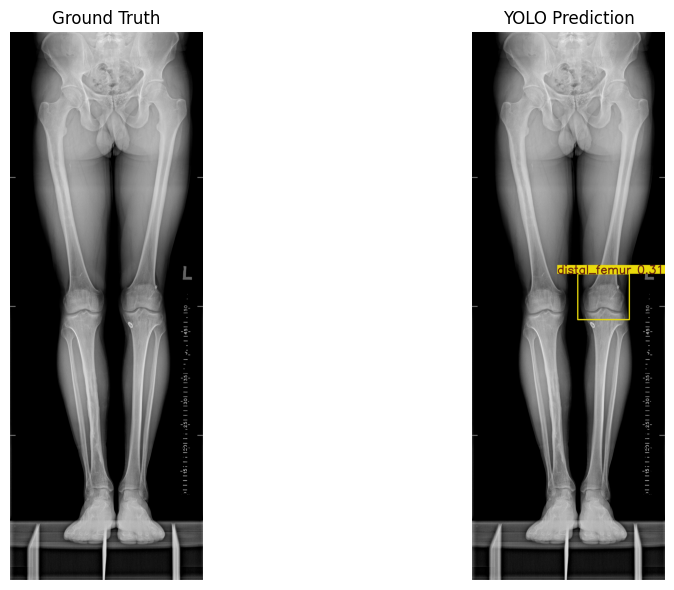

In [11]:
# Read test image paths
with open(os.path.join("yolo_data", "test.txt"), "r") as f:
    test_images = f.read().splitlines()

if test_images:
    sample_img = random.choice(test_images)
    print(f"Running inference on test sample: {sample_img}")
    
    # Run model prediction
    pred = model(sample_img)
    
    # Display results side-by-side
    fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Ground truth display
    img_pil = Image.open(sample_img)
    ax_gt.imshow(img_pil, cmap='gray')
    ax_gt.set_title("Ground Truth")
    ax_gt.axis("off")
    
    # Predicted rendering using ultralytics native plotting
    res_plotted = pred[0].plot()
    ax_pred.imshow(res_plotted, cmap='gray')
    ax_pred.set_title("YOLO Prediction")
    ax_pred.axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("No test images found.")